# installation/importation

In [ ]:
import netket as nk
import jax
from netket.operator.spin import sigmax,sigmaz
from jax import numpy as jnp
import matplotlib.pyplot as plt
import pickle
import optax
from flax import linen as nn
from functools import partial
from netket import jax as nkjax

In [ ]:
from qdisc import *

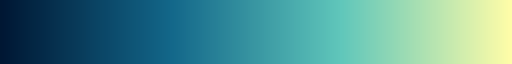

In [ ]:
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches

cmap_blue = LinearSegmentedColormap.from_list("custom_cmap", ['#001733', '#13678A', '#60C7BB', '#FFFDA8'])
cmap_blue

# Rydberg dataset

This notebook presents how to use QDisc to reproduce the results on the Rydberg atom dataset.

## dataset and training

The data are experimental snapshots obtained from a programmable Rydberg atom array. For more information, see the experimental paper:

https://www.nature.com/articles/s41586-021-03582-4

In [ ]:
## load the data (not provided here, this will give an error) ##
with open('data_RydbergExpL13 (1).pkl', 'rb') as f:
    data = pickle.load(f)

snapshots = data['dataset']
all_Rb = jnp.array(data['all_Rb'])
all_delta = jnp.array(data['all_delta'])
L = 13
N = L*L

In [ ]:
## cast them into a QDisc Dataset object ##
from qdisc.dataset.core import Dataset

dataset = Dataset(data=snapshots, thetas=[all_Rb, all_delta], data_type='discrete', local_dimension=2, local_states=jnp.array([0,1]))

In [ ]:
## create Transformer encoder and decoder ##
from qdisc.nn.core import Transformer_encoder
from qdisc.nn.core import Transformer_decoder
from qdisc.vae.core import VAEmodel

encoder = Transformer_encoder(latent_dim=5, d_model=8, num_heads=4, num_layers=3, data_type='discrete')
decoder = Transformer_decoder(d_model=8, num_heads=4, num_layers=3, data_type='discrete')

myvae = VAEmodel(encoder=encoder, decoder=decoder)

In [ ]:
## training and representation ##
from qdisc.vae.core import VAETrainer

myvaetrainer = VAETrainer(model=myvae, dataset=dataset)
key = jax.random.PRNGKey(6473)
num_epochs = 200
myvaetrainer.train(num_epochs=num_epochs, batch_size=3000, beta=0.45, gamma=0., key=key, printing_rate=10, re_shuffle=False)

Start training...
epoch=0 step=0 loss=119.569095476654 recon=117.79883895165419
logvar=[ 1.07415317  0.77997939  0.72378845 -0.93821395 -0.10032408]
epoch=10 step=0 loss=57.38552010440751 recon=56.24097025543754
logvar=[-0.07107329 -0.16698306 -0.34394546 -4.30383545 -0.06234075]
epoch=20 step=0 loss=56.43766805834163 recon=55.290590279764864
logvar=[-5.25762906e-02 -2.62134787e-02 -9.96280070e-02 -4.49870754e+00
 -2.65689430e-03]
epoch=30 step=0 loss=55.400550071167956 recon=54.15427316108366
logvar=[-0.24448012 -0.03299001 -0.01156073 -4.82013867 -0.0088556 ]
epoch=40 step=0 loss=54.83681362387403 recon=53.43010166759967
logvar=[-1.07542669 -0.01479255 -0.00726525 -4.86872305  0.01455821]
epoch=50 step=0 loss=54.53603219957166 recon=53.091557566642486
logvar=[-1.23756027e+00 -1.23709528e-02 -5.47091283e-03 -4.94531256e+00
  3.28441727e-03]
epoch=60 step=0 loss=54.43254836895113 recon=52.95765146657946
logvar=[-1.31491583e+00  7.30443888e-03 -1.43214228e-03 -5.12444969e+00
 -1.0674166

In [ ]:
data = myvaetrainer.get_data()

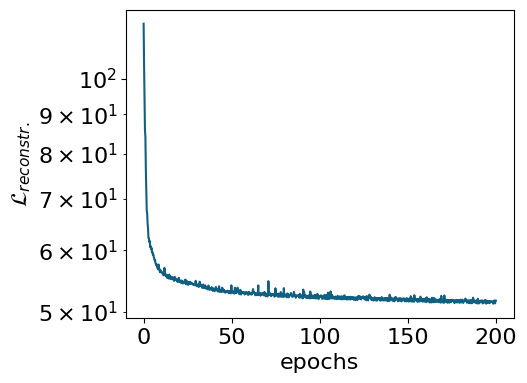

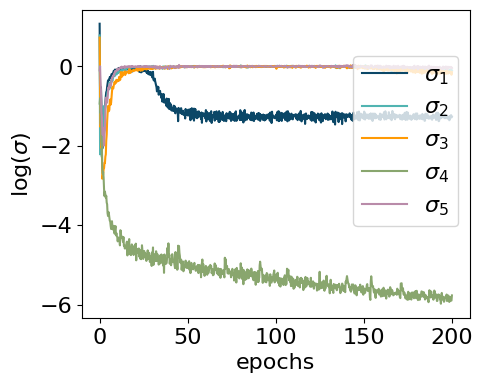

In [ ]:
myvaetrainer.plot_training(num_epochs = num_epochs)

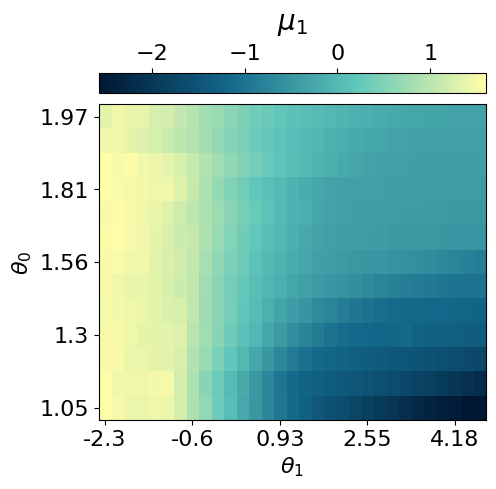

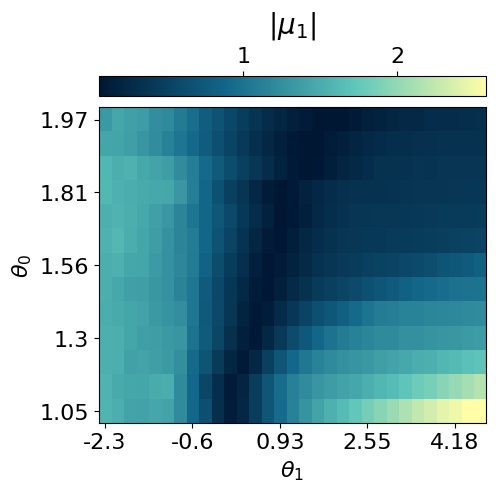

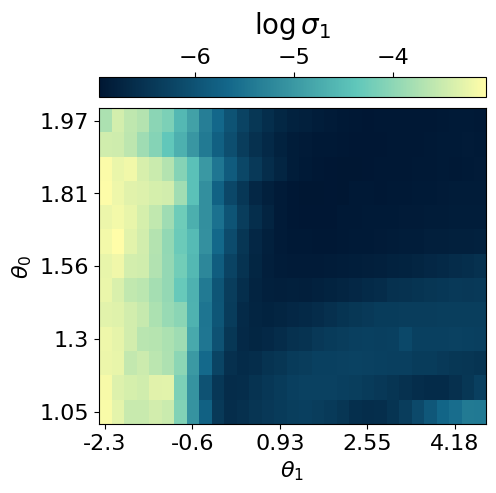

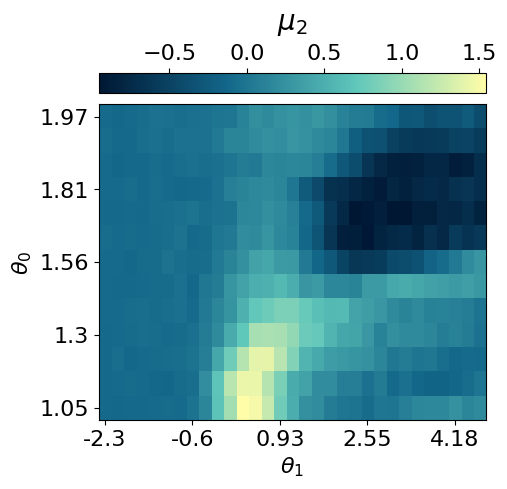

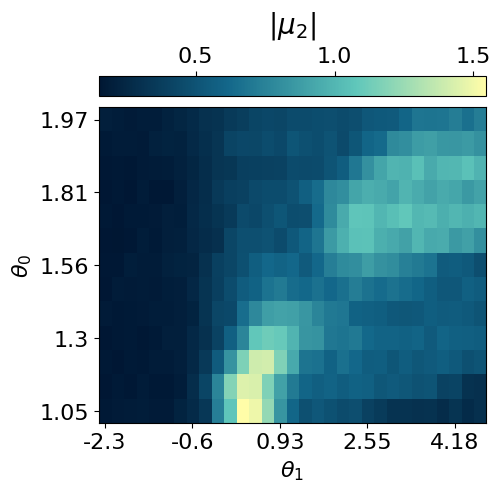

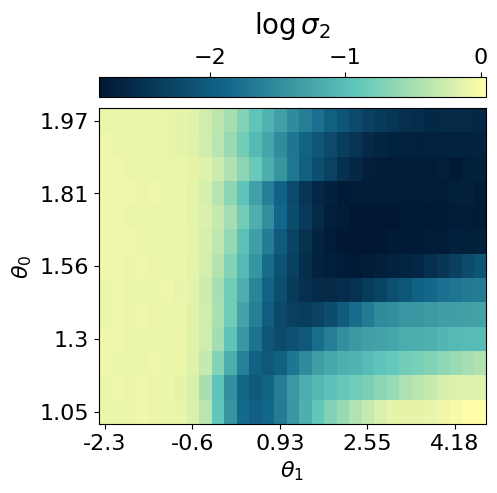

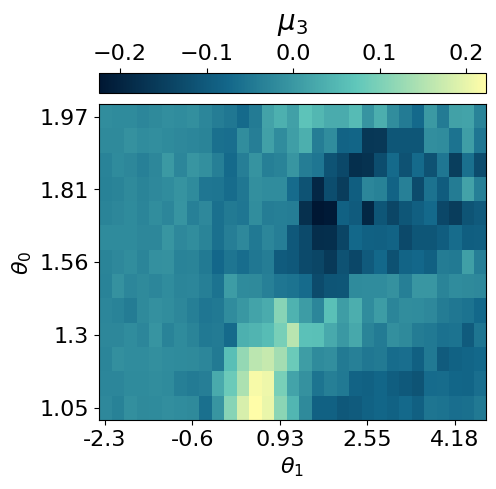

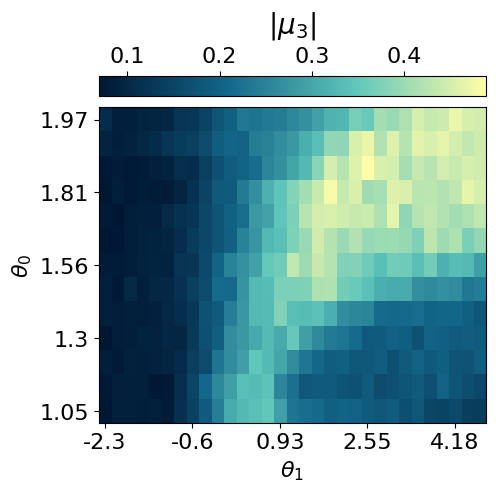

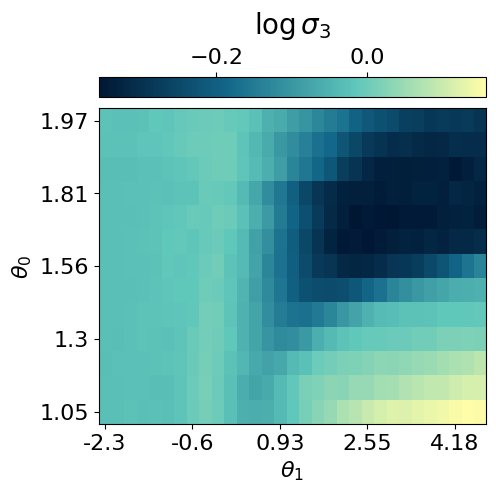

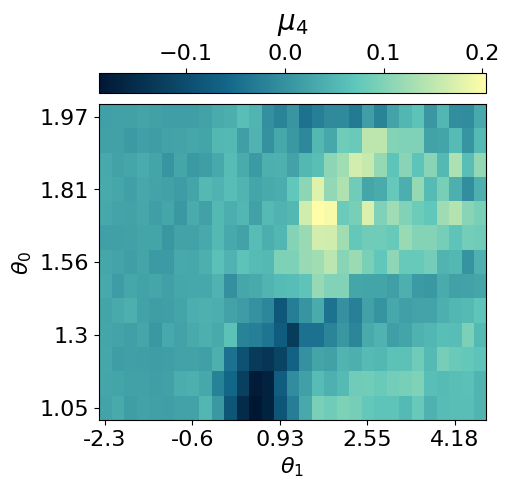

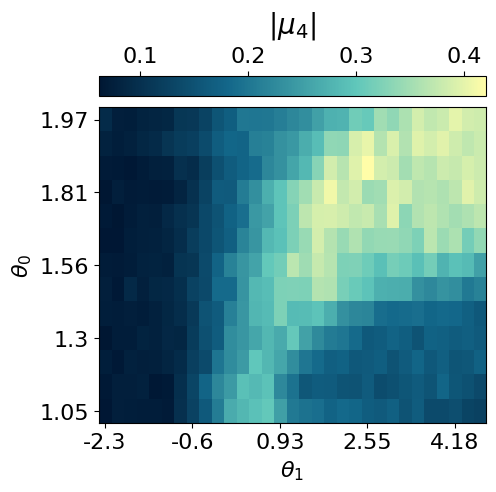

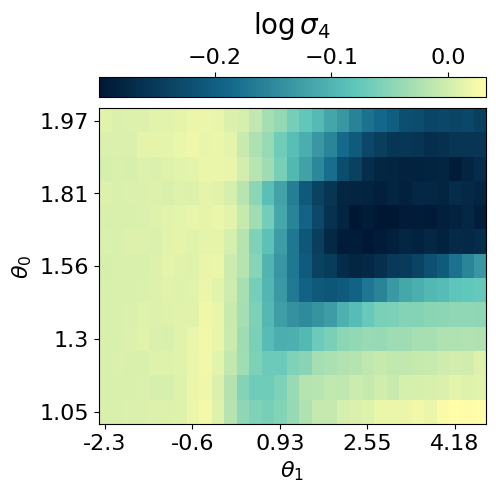

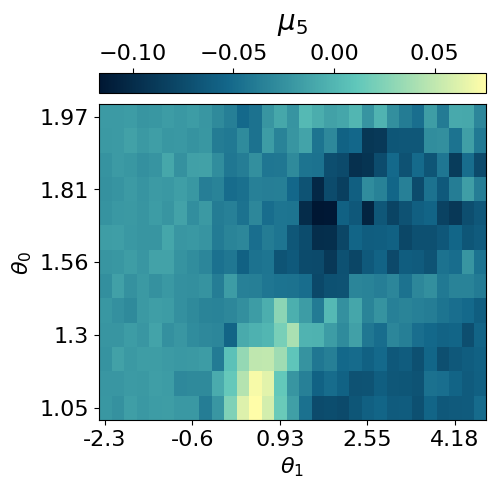

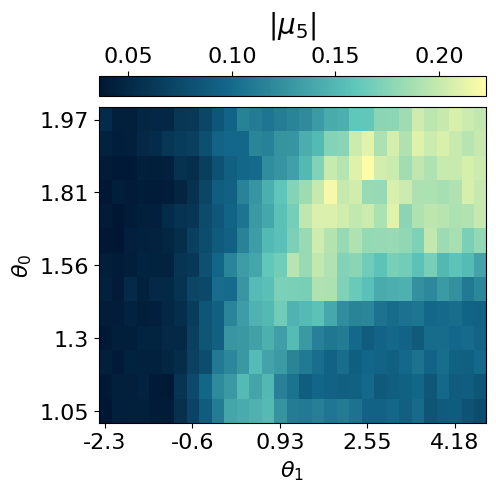

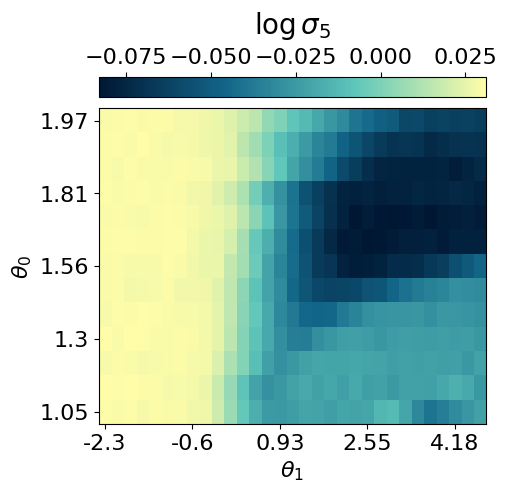

In [ ]:
latvar = myvaetrainer.compute_repr2d(theta_pair=(0,1), return_latvar = True)
myvaetrainer.plot_repr2d(theta_pair=(0,1),subplot=False)

In [ ]:
data.keys()

dict_keys(['params', 'history_loss', 'history_recon', 'history_logvar', 'latvar'])

In [ ]:
## saving the data ##
#data = myvaetrainer.get_data()

with open('RydbergExpL13_data_cpVAE2_QDisc.pkl', 'wb') as f:
    pickle.dump(data, f)

In [ ]:
## example how to load the data ##
with open('RydbergExpL13_data_cpVAE2_QDisc.pkl', 'rb') as f:
    data = pickle.load(f)

VAE_params = data['params']
myvaetrainer = VAETrainer(model=myvae, dataset=dataset)
key = jax.random.PRNGKey(0)
myvaetrainer.init_state(key, dataset.data[0,0])
myvaetrainer.state = myvaetrainer.state.replace(params=VAE_params)

## Exploring conditional probabilities with the decoder

In this section, we demonstrate how the **decoder of the cpVAE** can be used to gain further insight into the ordering of each phase by examining the **conditional probabilities**.

The procedure is as follows:
1. Specify the values of the latent variables corresponding to a region of interest in the latent space.
2. Identify the dataset samples associated with these latent values.
3. Input these samples into the decoder to compute the conditional probabilities of the spin configurations.


In [ ]:
latvar = myvaetrainer.latvar
latvar.keys()

dict_keys(['id_lat', 'theta_pair', 'mu0', 'mu0_abs', 'logvar0', 'mu1', 'mu1_abs', 'logvar1', 'mu2', 'mu2_abs', 'logvar2', 'mu3', 'mu3_abs', 'logvar3', 'mu4', 'mu4_abs', 'logvar4'])

In [ ]:
## a snake ordering is used, need it to map back to 2d for plotting ##
snake_idx = jnp.zeros((N,2))
for i in range(N):
  #position of each atoms using the snake numbering
  yp = i//L
  xp = (yp%2==0)*(i%L) + (yp%2==1)*(L-1-i%L)
  snake_idx = snake_idx.at[i].set(jnp.array([yp, xp]))

snake_idx = snake_idx.astype(jnp.int64)


def plot_cp(p_add_cluster):

    plt.rcParams['font.size'] = 16
    plt.figure(figsize=(5,5),dpi=75)

    p = jnp.mean(p_add_cluster,axis=0)[:,1]
    p2D = jnp.zeros((L,L))
    p2D = p2D.at[snake_idx[:,0], snake_idx[:,1]].set(p)

    plt.imshow(p2D, cmap=cmap_blue)

    cbar = plt.colorbar(orientation="horizontal", pad=0.03, location="top")

    cbar.set_label('conditional probabilities')

    plt.xlabel(r'$x$ position on the lattice')
    plt.ylabel(r'$y$ position on the lattice')

    x_tick_positions = [i for i in range(0,13,2)]
    x_tick_labels = [str(i) for i in range(1,14,2)]
    plt.xticks(x_tick_positions, x_tick_labels)

    y_tick_positions = x_tick_positions
    y_tick_labels = [str(14-i) for i in range(1,14,2)]
    plt.yticks(y_tick_positions, y_tick_labels)

    plt.show()

latvar = myvaetrainer.latvar

mu1 = latvar['mu1']
mu0 = latvar['mu0']

data_cond_prob = {}

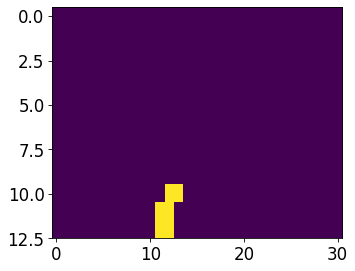

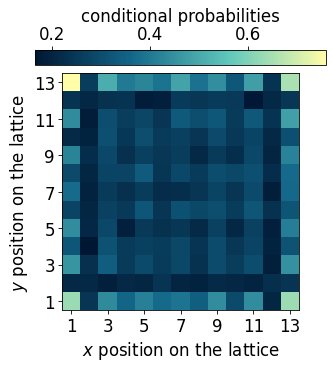

In [ ]:
## Additional cluter ##

mu1 = latvar['mu1']
idx_add_cluster = jnp.argwhere(mu1>1.25)

N = dataset.data.shape[-1]
data_add_cluster = dataset.data[idx_add_cluster[:,0],idx_add_cluster[:,1],:,:].reshape(-1,N)[:2000]

m = jnp.zeros((13,31))
for i in idx_add_cluster:
  m = m.at[i[0],i[1]].add(1)

plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,4),dpi=75)
plt.imshow(jnp.flipud(m), aspect='auto')
plt.show()


input_samples = dataset.data[idx_add_cluster[:,0],idx_add_cluster[:,1],:,:].reshape(-1,N)

key = jax.random.PRNGKey(0)
cp = myvaetrainer.get_cp(input_samples)

p_add_cluster = jnp.exp(cp)

plot_cp(p_add_cluster)

data_cond_prob['idx_add_cluster'] = idx_add_cluster
data_cond_prob['cp_add_cluster'] = cp

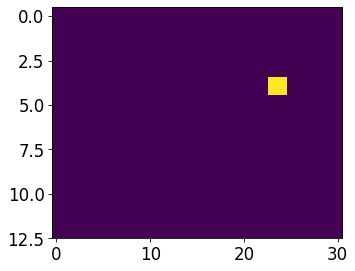

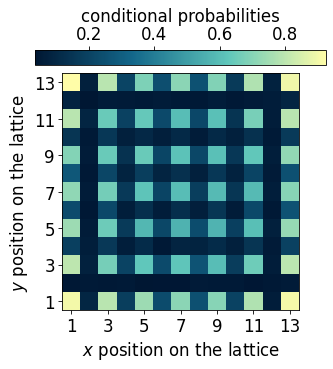

In [ ]:
## Striated phase ##

id_somewhere_else = jnp.argwhere(mu1<-0.95)
data_somewhere_else= dataset.data[id_somewhere_else[:,0],id_somewhere_else[:,1],:,:].reshape(-1,N)[:2000]


m = jnp.zeros((13,31))
for i in id_somewhere_else:
  m = m.at[i[0],i[1]].add(1)


plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,4),dpi=75)
plt.imshow(jnp.flipud(m), aspect='auto')

plt.show()


cp = myvaetrainer.get_cp(data_somewhere_else)
p_somewhere_else = jnp.exp(cp)

plot_cp(p_somewhere_else)

idx_striated = jnp.median(jnp.array(id_somewhere_else), axis=0)


data_cond_prob['idx_striated'] = idx_striated
data_cond_prob['cp_striated'] = cp

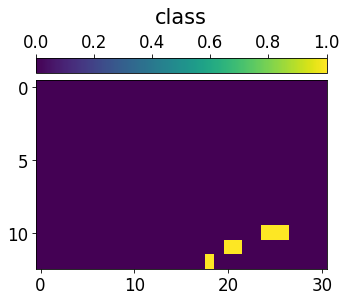

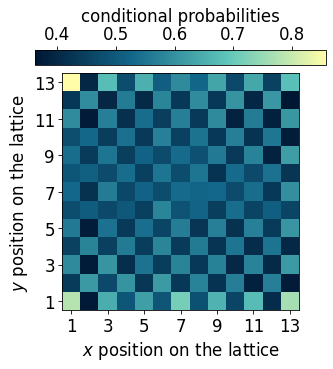

In [ ]:
## Checkerboard phase ##

mu0 = latvar['mu0']
id_somewhere_else = jnp.argwhere(((mu0<-1.45)*1 + (mu0>-1.55)*1)==2)

#just take the ones starting with 1 to not have degeneracies effect
data_somewhere_else = dataset.data[id_somewhere_else[:,0],id_somewhere_else[:,1],:,:].reshape(-1,N)[:2000]#[jnp.argwhere(data_somewhere_else[:,0]==1)[:,0]]
#data_somewhere_else = data_somewhere_else[jnp.argwhere(data_somewhere_else[:,0]==1)[:,0]]


m = jnp.zeros((13,31))
for i in id_somewhere_else:
  m = m.at[i[0],i[1]].add(1)


plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,4),dpi=75)
plt.imshow(jnp.flipud(m), aspect='auto')
cbar = plt.colorbar(orientation="horizontal", pad=0.03, location="top")
cbar.set_label(r'class', fontsize=20, labelpad=10)
plt.show()

cp = myvaetrainer.get_cp(data_somewhere_else)
p_somewhere_else = jnp.exp(cp)

plot_cp(p_somewhere_else)

idx_check = jnp.median(jnp.array(id_somewhere_else), axis=0)


data_cond_prob['idx_check'] = idx_check
data_cond_prob['cp_check'] = cp

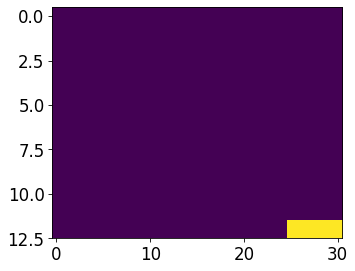

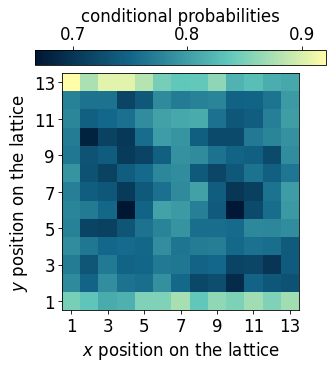

In [ ]:
## Fully loaded lattice ##

id_somewhere_else = jnp.argwhere(mu0<-2.2)

data_somewhere_else= dataset.data[id_somewhere_else[:,0],id_somewhere_else[:,1],:,:].reshape(-1,N)[:2000]


m = jnp.zeros((13,31))
for i in id_somewhere_else:
  m = m.at[i[0],i[1]].add(1)


plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,4),dpi=75)
plt.imshow(jnp.flipud(m), aspect='auto')
plt.show()


cp = myvaetrainer.get_cp(data_somewhere_else)
p_somewhere_else = jnp.exp(cp)
p = jnp.mean(p_somewhere_else,axis=0)[:,1]


plot_cp(p_somewhere_else)

idx_full = jnp.median(jnp.array(id_somewhere_else), axis=0)


data_cond_prob['idx_full'] = idx_full
data_cond_prob['cp_full'] = cp

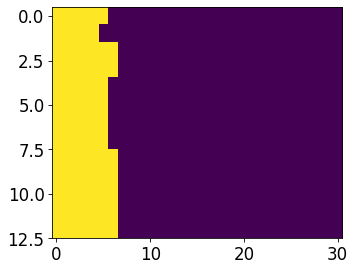

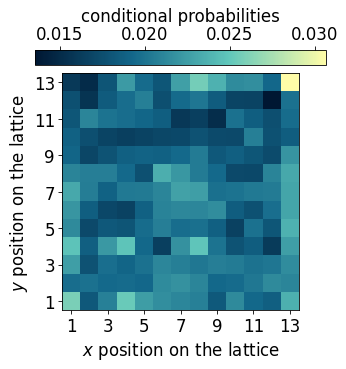

In [ ]:
## Empty lattice ##

id_somewhere_else = jnp.argwhere(mu0>1.2)

data_somewhere_else= dataset.data[id_somewhere_else[:,0],id_somewhere_else[:,1],:,:].reshape(-1,N)[:2000,:]


m = jnp.zeros((13,31))
for i in id_somewhere_else:
  m = m.at[i[0],i[1]].add(1)


plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,4),dpi=75)
plt.imshow(jnp.flipud(m), aspect='auto')
plt.show()


cp = myvaetrainer.get_cp(data_somewhere_else)
p_somewhere_else = jnp.exp(cp)
p = jnp.mean(p_somewhere_else,axis=0)[:,1]


plot_cp(p_somewhere_else)

idx_empty = jnp.median(jnp.array(id_somewhere_else), axis=0)


data_cond_prob['idx_empty'] = idx_empty
data_cond_prob['cp_empty'] = cp

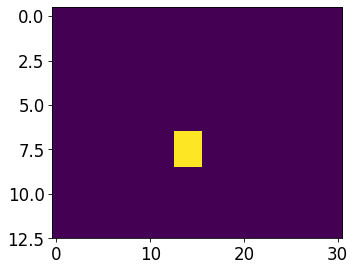

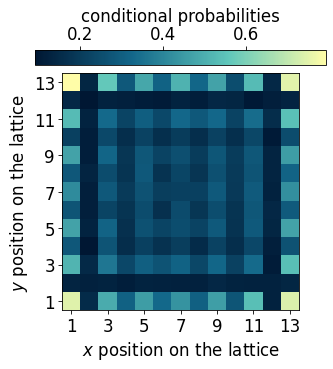

In [ ]:
## Edge ordered phase ##

id_somewhere_else = jnp.argwhere(((mu1<1)*1 + (mu0>-.5)*1 + (mu0<0)*1 + (mu1>0.4)*1)==4)

data_somewhere_else= dataset.data[id_somewhere_else[:,0],id_somewhere_else[:,1],:,:].reshape(-1,N)[:2000,:]


m = jnp.zeros((13,31))
for i in id_somewhere_else:
  m = m.at[i[0],i[1]].add(1)


plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,4),dpi=75)
plt.imshow(jnp.flipud(m), aspect='auto')
plt.show()


cp = myvaetrainer.get_cp(data_somewhere_else)
p_somewhere_else = jnp.exp(cp)
p = jnp.mean(p_somewhere_else,axis=0)[:,1]


plot_cp(p_somewhere_else)

idx_edge = jnp.median(jnp.array(id_somewhere_else), axis=0)


data_cond_prob['idx_edge'] = idx_edge
data_cond_prob['cp_edge'] = cp

In [ ]:
data['latvar'] = latvar
data['data_cond_prob'] = data_cond_prob

with open('RydbergExpL13_data_cpVAE2_QDisc.pkl', 'wb') as f:
    pickle.dump(data, f)

## Symbolic regression

In this section, we use `QDisc.SR.SymbolicRegression` with the `'genetic'` search space and the SR1 objective to find a symbolic function that characterizes the additional cluster.

In [ ]:
#import pysr
import numpy as np
from pysr import PySRRegressor #this take around 7min
import sympy as sp
import pickle
from jax import numpy as jnp
import jax
from matplotlib import pyplot as plt

[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliapkg/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliacall/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/pysr/juliapkg.json
[juliapkg] Locating Julia 1.10.3 - 1.11
[juliapkg] Using Julia 1.11.5 at /usr/local/bin/julia
[juliapkg] Using Julia project at /root/.julia/environments/pyjuliapkg
[juliapkg] Writing Project.toml:
           | [deps]
           | PythonCall = "6099a3de-0909-46bc-b1f4-468b9a2dfc0d"
           | OpenSSL_jll = "458c3c95-2e84-50aa-8efc-19380b2a3a95"
           | SymbolicRegression = "8254be44-1295-4e6a-a16d-46603ac705cb"
           | Serialization = "9e88b42a-f829-5b0c-bbe9-9e923198166b"
           | 
           | [compat]
           | PythonCall = "=0.9.26"
           | OpenSSL_jll = "~3.0"
           | SymbolicRegression = "~1.11"
           | Serialization = "^1"
[juliapkg] Installing packages:
           | impo

In [ ]:
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches

custom_palette = ['#001733', '#13678A', '#60C7BB', '#FFFDA8']
cmap_blue = LinearSegmentedColormap.from_list("custom_cmap", custom_palette)
custom_palette = ['#221226','#633D55','#A3648B','#F7FAFF']
cmap_purple = LinearSegmentedColormap.from_list("custom_cmap", custom_palette)
custom_palette = ['#0D090D','#365925','#DAF2B6']
cmap_green3 = LinearSegmentedColormap.from_list("custom_cmap", custom_palette)

In [ ]:
id_add_cluster = jnp.argwhere(mu1>1.2)
id_add_cluster

Array([[ 0, 11],
       [ 0, 12],
       [ 0, 13],
       [ 1, 11],
       [ 1, 12],
       [ 2, 12],
       [ 2, 13]], dtype=int64)

In [ ]:
with open('data_RydbergExpL13.pkl', 'rb') as f:
    data = pickle.load(f)

snapshots = data['dataset']
all_Rb = jnp.array(data['all_Rb'])
all_delta = jnp.array(data['all_delta'])
L = 13
N = L*L


idx_add_cluster = jnp.array([[ 0, 11],
       [ 0, 12],
       [ 0, 13],
       [ 1, 11],
       [ 1, 12],
       [ 2, 12],
       [ 2, 13]])


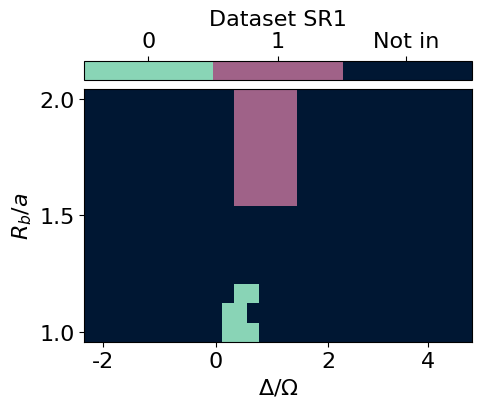

In [ ]:
## specify the indexe of the data labelled as outide and visualize ##
#id_add_cluster = jnp.argwhere(mu1<-1.2)

classes = 3*jnp.ones((13,31))
for i in idx_add_cluster:
  classes = classes.at[i[0],i[1]].set(1)


classes = classes.at[7:,12:17].set(2)


plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,4),dpi=100)


cmap_2bins = ListedColormap([cmap_blue(0.75), cmap_purple(0.65), cmap_blue(0.)])

im = plt.imshow(jnp.flipud(classes), aspect='auto', cmap=cmap_2bins)
cbar = plt.colorbar(im, orientation="horizontal", pad=0.03, location="top", ticks=[1.33, 2, 2.66])
cbar.set_ticklabels(['0', '1', 'Not in'])
cbar.set_label(r'Dataset SR1')

plt.xlabel(r'$\Delta/\Omega$')
plt.ylabel(r'$R_b/a$')

x_tick_positions = [1, 10, 19, 27]  # Positions for the ticks
x_tick_labels = ['-2', '0', '2', '4']  # Labels for the ticks
plt.xticks(x_tick_positions, x_tick_labels)

y_tick_positions = [0,6,12]  # Positions for the ticks
y_tick_labels = ['2.0', '1.5', '1.0']  # Labels for the ticks
plt.yticks(y_tick_positions, y_tick_labels)

plt.show()

data = snapshots

all_corners = [[0,1,25,24], [12,13,11,14], [156,155,157,154], [168,167,143,144]]
data_corners = jnp.concatenate([snapshots[..., corners] for corners in all_corners], axis=2)


dataset_corners = Dataset(data=data_corners, thetas=[all_Rb, all_delta], data_type='discrete', local_dimension=2, local_states=jnp.array([0,1]))

cluster_idx_in = jnp.argwhere(classes==1)
cluster_idx_out = jnp.argwhere(classes==2)

mySR = SymbolicRegression(dataset = dataset_corners,
                          cluster_idx_in = cluster_idx_in,
                          cluster_idx_out = cluster_idx_out,
                          objective='SR1',
                          search_space = "2_body_correlator" )



In [ ]:
## restrict the data to the corners of the lattice ##
from qdisc.sr.core import SymbolicRegression

data = snapshots

all_corners = [[0,1,25,24], [12,13,11,14], [156,155,157,154], [168,167,143,144]]
data_corners = jnp.concatenate([snapshots[..., corners] for corners in all_corners], axis=2)


dataset_corners = Dataset(data=data_corners, thetas=[all_Rb, all_delta], data_type='discrete', local_dimension=2, local_states=jnp.array([0,1]))

cluster_idx_in = jnp.argwhere(classes==1)
cluster_idx_out = jnp.argwhere(classes==2)

mySR = SymbolicRegression(dataset = dataset_corners,
                          cluster_idx_in = cluster_idx_in,
                          cluster_idx_out = cluster_idx_out,
                          objective='SR1',
                          search_space = "genetic",
                          shift_data = False)



PySRRegressor imported


In [ ]:
## search ##
all_perf, all_eqs, all_terms = mySR.train(
    key = jax.random.PRNGKey(645),
    dataset_size = 5000,
    random_state = 123,     # seed for reproductibility
    niterations = 20,       # Number of iterations to search
    binary_operators = ["+", "*", "-"],  # Allowed binary operations
    elementwise_loss = "loss(x,y) = -y*log(1/(1+exp(-x)))-(1-y)*log(1-1/(1+exp(-x)))",  # sigmoid loss for SR1
    maxsize = 20,            # max complexity of the equations
    progress = True,         # Show progress during training
    extra_sympy_mappings = {"C": "C"}, # Allow PySR to use constants
    batching = True, #batching, usually big dataset
    batch_size = 1000,
    turbo = True,
    deterministic = True, #for reproductibility
    parallelism = 'serial')

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
INFO:pysr.sr:Compiling Julia backend...
   Resolving package versions...
   Installed ThreadingUtilities ─────────────── v0.5.5
   Installed BitTwiddlingConvenienceFunctions ─ v0.1.6
   Installed LayoutPointers ─────────────────── v0.1.17
   Installed HostCPUFeatures ────────────────── v0.1.18
   Installed ManualMemory ───────────────────── v0.1.8
   Installed SIMDTypes ──────────────────────── v0.1.0
   Installed VectorizationBase ──────────────── v0.21.72
   Installed LoopVectorization ──────────────── v0.12.173
   Installed SLEEFPirates ───────────────────── v0.6.43
   Installed PolyesterWeave ─────────────────── v0.2.2
   Installed UnPack ─────────────────────────── v1.0.2
   Installed CloseOpenIntervals ─────────────── v0.1.13
   Installed StaticArrayInterface ───────────── v1.9.0
    


Expressions evaluated per second: 9.500e+02
Progress: 46 / 620 total iterations (7.419%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.940e-01  0.000e+00  y = -0.081661
3           6.346e-01  4.473e-02  y = x₁ + x₃
5           6.208e-01  1.102e-02  y = (x₃ * 2.1711) + x₁
7           6.018e-01  1.549e-02  y = (x₃ + (x₁ + -0.42624)) + x₃
9           5.773e-01  2.080e-02  y = x₁ + (((x₃ - 0.21415) * 3.0877) + x₂)
11          5.772e-01  1.125e-04  y = (((x₃ + (x₁ + x₃)) + -0.60713) + x₂) * 1.4292
13          5.743e-01  2.526e-03  y = (x₃ * x₀) + (x₂ + ((-0.70466 + (x₃ + x₁)) + x₃))
15          5.731e-01  1.021e-03  y = ((x₀ * (x₃ * 1.3817)) + (((x₂ + -0.70466) + x₃) + x₁))...
                                       + x₃
17          5.726e-01  4.610e-04  y = ((x₀ * (x₃ * 0.91296)) +

[ Info: Final population:
[ Info: Results saved to:


  - outputs/20260213_091433_AHqlFf/hall_of_fame.csv


In [ ]:
## look at the last equation ##
i = 7
perf = all_perf[i]
equation_sympy = all_eqs[i]
terms = all_terms[i]
print('equation {}: {}, terms: {}'.format(i,perf,terms))
print(equation_sympy)
print('\n')


equation 7: 0.6969000101089478, terms: [1, x1**2, x2**2, x3, x0*x3, x1*x2]
x0*x3 + x1**2 + 2*x1*x2 + x2**2 + 2.3751783*x3 - 0.72377163




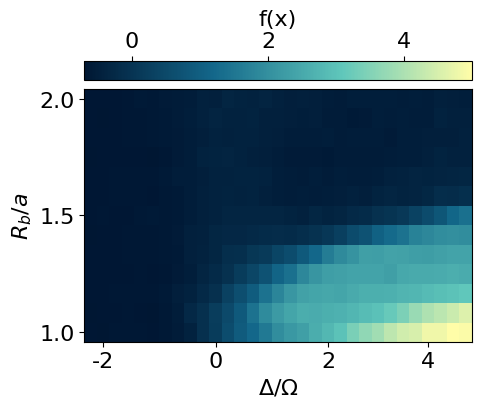

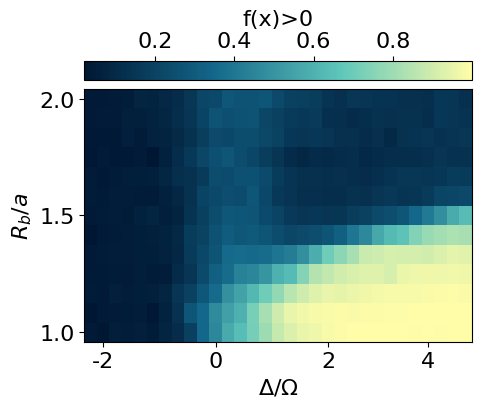

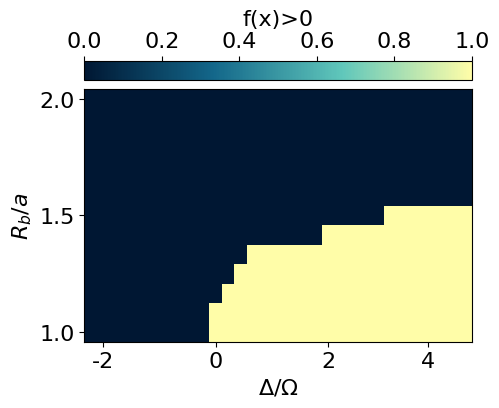

[ColabKernelApp] WARNING | Error caught during object inspection: Can't clean for JSON: <class 'sympy.core.symbol.Symbol'>


In [ ]:
import sympy as sp
import jax
import jax.numpy as jnp

f_str = '2.0894327*x0*x3 + 2.0894327*x1*x2 + 0.857685211456824*x1 + x2 + 2.0894327*x3 - 0.776886377897628'
f_str = 'x0*x3 + x1 + 2*x1*x2 + x2 + 2.3751783*x3 - 0.72377163'

f_sympy = sp.sympify(f_str)
x0, x1, x2, x3 = sp.symbols('x0 x1 x2 x3')
f_callable = sp.lambdify([x0, x1, x2, x3], f_sympy, 'jax')

all_corners = [[0,1,25,24], [12,13,11,14], [156,155,157,154], [168,167,143,144]]
snapshots_coners = jnp.concatenate([snapshots[..., corners] for corners in all_corners], axis=2)


all_predictions = f_callable(snapshots_coners[:,:,:,0], snapshots_coners[:,:,:,1], snapshots_coners[:,:,:,2], snapshots_coners[:,:,:,3])



plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,4),dpi=100)


plt.imshow(jnp.flipud(jnp.mean(all_predictions, axis=-1)), cmap=cmap_blue, aspect='auto')
cbar = plt.colorbar(orientation="horizontal", pad=0.03, location="top")
cbar.set_label(r'f(x)')

plt.xlabel(r'$\Delta/\Omega$')
plt.ylabel(r'$R_b/a$')

x_tick_positions = [1, 10, 19, 27]  # Positions for the ticks
x_tick_labels = ['-2', '0', '2', '4']  # Labels for the ticks
plt.xticks(x_tick_positions, x_tick_labels)

y_tick_positions = [0,6,12]  # Positions for the ticks
y_tick_labels = ['2.0', '1.5', '1.0']  # Labels for the ticks
plt.yticks(y_tick_positions, y_tick_labels)

plt.show()


plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,4),dpi=100)


plt.imshow(jnp.flipud(jnp.mean(all_predictions>0, axis=-1)), cmap=cmap_blue, aspect='auto')
cbar = plt.colorbar(orientation="horizontal", pad=0.03, location="top")
cbar.set_label(r'f(x)>0')

plt.xlabel(r'$\Delta/\Omega$')
plt.ylabel(r'$R_b/a$')

x_tick_positions = [1, 10, 19, 27]  # Positions for the ticks
x_tick_labels = ['-2', '0', '2', '4']  # Labels for the ticks
plt.xticks(x_tick_positions, x_tick_labels)

y_tick_positions = [0,6,12]  # Positions for the ticks
y_tick_labels = ['2.0', '1.5', '1.0']  # Labels for the ticks
plt.yticks(y_tick_positions, y_tick_labels)

plt.show()


plt.rcParams['font.size'] = 16
plt.figure(figsize=(5,4),dpi=100)


plt.imshow(jnp.flipud(jnp.mean(all_predictions, axis=-1)>0), cmap=cmap_blue, aspect='auto')
cbar = plt.colorbar(orientation="horizontal", pad=0.03, location="top")
cbar.set_label(r'f(x)>0')

plt.xlabel(r'$\Delta/\Omega$')
plt.ylabel(r'$R_b/a$')

x_tick_positions = [1, 10, 19, 27]  # Positions for the ticks
x_tick_labels = ['-2', '0', '2', '4']  # Labels for the ticks
plt.xticks(x_tick_positions, x_tick_labels)

y_tick_positions = [0,6,12]  # Positions for the ticks
y_tick_labels = ['2.0', '1.5', '1.0']  # Labels for the ticks
plt.yticks(y_tick_positions, y_tick_labels)

plt.show()

Using our prior knowledge of the system, we can construct an order parameter by using the found correlator on the corner and subtracting the correlations on the edges and in the bulk.

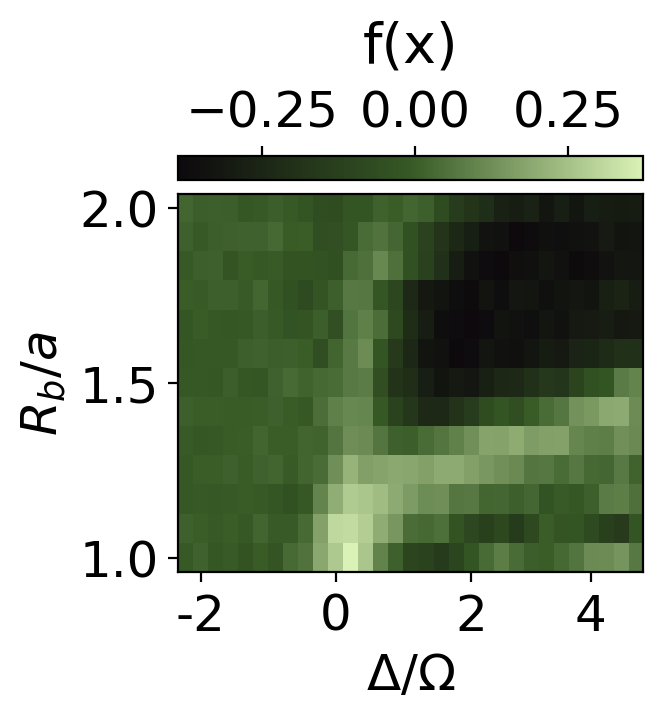

In [ ]:
def compute_correlation_bulk_pos(x):
  """Computes the bulk correlation of a single configuration."""
  c = []
  for i in range(N):
    if i>L and i<(L*L-L) and i%L!=0 and (i+1)%L!=0:
      yi = i//L
      xi = (yi%2==0)*(i%L) + (yi%2==1)*(L-1-i%L)
      j = i+1
      c.append(x[i]*x[j])
  return jnp.mean(jnp.array(c),axis=-1)/2

def compute_correlation_edges_pos(x):
  """Computes the edge correlation of a single configuration."""
  c = []
  for i in range(L-1):
    c.append(x[i]*x[i+1])
  for i in range(L*L-L,L*L-1):
    c.append(x[i]*x[i+1])
  for i in range(L-1,L*L,L):
    c.append(x[i]*x[i+1])
  for i in range(0,L*L,L):
    c.append(x[i]*x[i+25])

  return jnp.mean(jnp.array(c),axis=-1)

def compute_correlation_corner(x):
  """Computes the corner correlation of a single configuration."""
  c = []

  all_corners = [[0,1,25,24], [12,13,11,14], [156,155,157,154], [168,167,143,144]]
  x_corner = jnp.concatenate([x[None, corners] for corners in all_corners], axis=0)

  c.append(x_corner[:,0]*x_corner[:,3])
  c.append(2*x_corner[:,1]*x_corner[:,2])



  co = jnp.abs(jnp.mean(jnp.array(c).reshape(-1),axis=-1))
  ed = jnp.abs(compute_correlation_edges_pos(x))
  bu = jnp.abs(compute_correlation_bulk_pos(x))



  return  co - ed - bu




compute_correlation_corner_vmap = jax.vmap(jax.vmap(jax.vmap(compute_correlation_corner)))


plt.rcParams['font.size'] = 18
plt.figure(figsize=(3,3),dpi=200)

#S = data_exact['S']
cor = jnp.mean(compute_correlation_corner_vmap(snapshots*2-1), axis=-1)
plt.imshow(jnp.flipud(cor), cmap=cmap_green3, aspect='auto')

cbar = plt.colorbar(orientation="horizontal", pad=0.03, location="top")
cbar.set_label(r'f(x)', fontsize=20, labelpad=10)


plt.xlabel(r'$\Delta/\Omega$')
plt.ylabel(r'$R_b/a$')

x_tick_positions = [1, 10, 19, 27]  # Positions for the ticks
x_tick_labels = ['-2', '0', '2', '4']  # Labels for the ticks
plt.xticks(x_tick_positions, x_tick_labels)

y_tick_positions = [0,6,12]  # Positions for the ticks
y_tick_labels = ['2.0', '1.5', '1.0']  # Labels for the ticks
plt.yticks(y_tick_positions, y_tick_labels)


#cbar.set_label(r'$\langle Z(r_j)Z(r_i) \rangle$  $(r_j,r_i)\in NN$')

#plt.title('S')
plt.show()



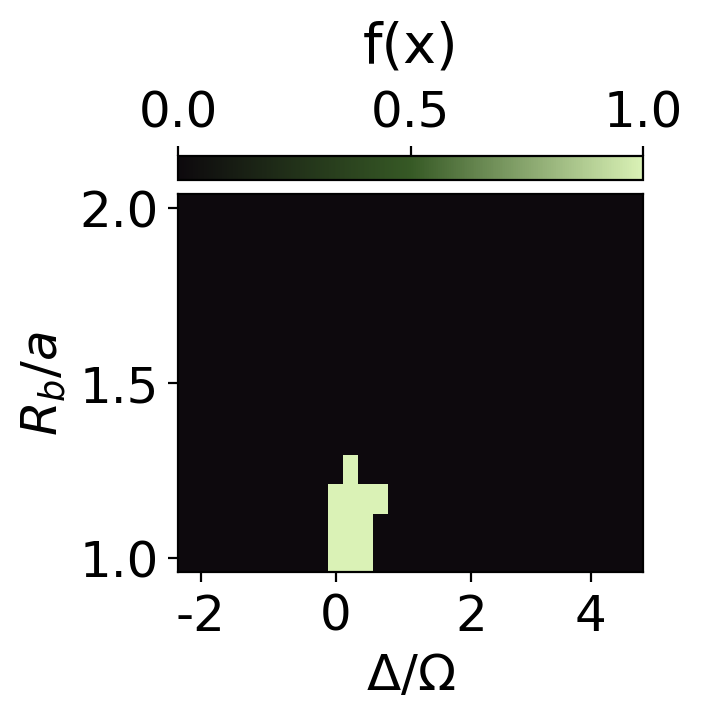

In [ ]:
plt.rcParams['font.size'] = 18
plt.figure(figsize=(3,3),dpi=200)


plt.imshow(jnp.flipud(cor>0.2), cmap=cmap_green3, aspect='auto')

cbar = plt.colorbar(orientation="horizontal", pad=0.03, location="top")
cbar.set_label(r'f(x)', fontsize=20, labelpad=10)


plt.xlabel(r'$\Delta/\Omega$')
plt.ylabel(r'$R_b/a$')

x_tick_positions = [1, 10, 19, 27]  # Positions for the ticks
x_tick_labels = ['-2', '0', '2', '4']  # Labels for the ticks
plt.xticks(x_tick_positions, x_tick_labels)

y_tick_positions = [0,6,12]  # Positions for the ticks
y_tick_labels = ['2.0', '1.5', '1.0']  # Labels for the ticks
plt.yticks(y_tick_positions, y_tick_labels)


#cbar.set_label(r'$\langle Z(r_j)Z(r_i) \rangle$  $(r_j,r_i)\in NN$')

#plt.title('S')
plt.show()